# S&P 500 주식 데이터 클렌징 및 다각도 분석 (2000년 ~ 2019년)

본 주피터 노트북은 `S&P 500 과거 데이터.csv` 파일을 바탕으로 2000년 초부터 2019년 말까지의 주가 데이터를 전처리(Data Cleansing)하고, Pandas를 활용하여 다각도로 분석한 후, 종가 기준 시계열 라인 그래프를 시각화합니다.

---

### 주요 작업 순서
1. **데이터 불러오기 및 클렌징 (Data Cleansing)**
   - BOM 인코딩 처리 및 공백/콤마/퍼센트(%) 기호 제거
   - `날짜` 컬럼의 `datetime` 변환 및 정렬
   - 수치형 컬럼(`종가`, `시가`, `고가`, `저가`, `변동 %`) 실수(Float) 변환
   - 2000년 1월 1일 ~ 2019년 12월 31일 필터링 및 중복값/결측치 처리
2. **다각도 데이터 분석 (Multi-faceted Analysis with Pandas)**
   - 가격 지표별 기술 통계량 산출 (`describe()`)
   - 파생 변수 생성: 일간 수익률, 이동평균선 (20일, 60일, 120일, 200일), 고점 대비 하락률 (Drawdown)
   - 연도별 성과 분석: 연초가, 연말가, 연간 수익률, 연중 최고/최저가, 연간 변동폭
   - 월별/계절성(Seasonality) 분석: 월별 평균 수익률 및 상승 마감 확률(승률)
   - 위험 지표 분석: 연율화 변동성, 역사적 최대 낙폭 (MDD, Maximum Drawdown)
   - 역대 일일 최대 상승일(폭등일) Top 5 및 최대 하락일(폭락일) Top 5
3. **종가 기준 라인 그래프 시각화 (Visualization)**
   - 종가 추이 및 이동평균선(20일, 60일, 200일) 라인 차트
   - 닷컴 버블, 2008년 글로벌 금융위기 저점, 2019년 사상 최고가 돌파 지점 주석(Annotation) 표시
   - 하단 고점 대비 하락률(Drawdown) 영역 차트 연계 시각화


## 1. 라이브러리 임포트 및 시각화 환경 설정
- 데이터 분석을 위한 `pandas`, `numpy` 임포트
- 시각화를 위한 `matplotlib.pyplot` 임포트
- 윈도우 환경 한글 폰트(`Malgun Gothic`) 및 음수 기호(-) 깨짐 방지 설정
- CSV 파일 경로 확인 및 자동 탐색


In [ ]:
from pathlib import Path
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 경고 메시지 무시
warnings.filterwarnings("ignore")

# 1. 시각화 한글 폰트 및 마이너스 부호 설정 (Windows 맑은 고딕)
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 2. 파일 경로 자동 탐색 (현재 폴더 및 작업 폴더)
csv_candidates = [
    Path("S&P 500 과거 데이터.csv"),
    Path(r"c:\workAnti\S&P 500 과거 데이터.csv"),
    Path(r"c:\work\S&P 500 과거 데이터.csv"),
]

csv_file = None
for candidate in csv_candidates:
    if candidate.exists():
        csv_file = candidate
        break

if csv_file is None:
    raise FileNotFoundError("S&P 500 과거 데이터.csv 파일을 찾을 수 없습니다.")

print(f"데이터 파일 로드 경로: {csv_file.resolve()}")


데이터 파일 로드 경로: C:\workAnti\S&P 500 과거 데이터.csv


## 2. 데이터 로드 및 데이터 클렌징 (Data Cleansing)
- 원본 CSV 파일 로드 (`utf-8-sig`)
- 날짜 컬럼의 공백 제거 (`2019- 11- 14` -> `2019-11-14`) 및 `pd.to_datetime` 변환
- 가격 컬럼(`종가`, `시가`, `고가`, `저가`)의 천 단위 쉼표(`,`) 제거 후 `float` 변환
- `변동 %` 컬럼의 퍼센트(`%`) 기호 제거 후 `float` 변환
- 전량 결측치인 `거래량` 컬럼 정리
- 2000년 1월 1일 ~ 2019년 12월 31일 구간 필터링
- 날짜 기준 오름차순(과거 -> 최근) 정렬 및 인덱스 초기화


In [ ]:
# 1. 원본 데이터 불러오기
raw_df = pd.read_csv(csv_file, encoding="utf-8-sig")

print("[원본 데이터 정보]")
print(f"- 원본 행/열 수: {raw_df.shape[0]:,}행, {raw_df.shape[1]}열")
print("- 원본 컬럼 목록:", raw_df.columns.tolist())
display(raw_df.head(3))

# 2. 데이터 클렌징 진행
df = raw_df.copy()

# 2-1. 날짜 정제: 공백 제거 및 datetime 형식 변환
df["날짜"] = pd.to_datetime(df["날짜"].astype(str).str.replace(" ", "", regex=False))

# 2-2. 가격 컬럼 정제: 천단위 쉼표(,) 제거 후 실수(float) 변환
price_cols = ["종가", "시가", "고가", "저가"]
for col in price_cols:
    df[col] = df[col].astype(str).str.replace(",", "", regex=False).astype(float)

# 2-3. 변동 % 컬럼 정제: % 기호 제거 후 실수(float) 변환
df["변동 %"] = df["변동 %"].astype(str).str.replace("%", "", regex=False).astype(float)

# 2-4. 거래량 컬럼 확인 (전량 결측치 여부 확인 후 제외)
vol_null_count = df["거래량"].isna().sum()
print(f"\n- 거래량 컬럼 결측치 수: {vol_null_count:,}개 / {len(df):,}개 (전량 결측치)")
df = df.drop(columns=["거래량"], errors="ignore")

# 2-5. 2000년 초부터 2019년 말까지 필터링 (2000-01-01 ~ 2019-12-31)
start_date = "2000-01-01"
end_date = "2019-12-31"
df = df[(df["날짜"] >= start_date) & (df["날짜"] <= end_date)].copy()

# 2-6. 중복 날짜 확인 및 제거
dup_count = df.duplicated(subset=["날짜"]).sum()
if dup_count > 0:
    df = df.drop_duplicates(subset=["날짜"], keep="first")
print(f"- 중복 날짜 제거: {dup_count}건")

# 2-7. 과거순(오름차순) 정렬 및 인덱스 초기화
df = df.sort_values("날짜").reset_index(drop=True)

print("\n[클렌징 완료 데이터 요약]")
print(f"- 분석 기간: {df['날짜'].min().strftime('%Y-%m-%d')} ~ {df['날짜'].max().strftime('%Y-%m-%d')}")
print(f"- 총 거래일수: {len(df):,}일")
print(f"- 컬럼별 결측치 수:\n{df.isna().sum()}")
display(df.head())


[원본 데이터 정보]
- 원본 행/열 수: 5,000행, 7열
- 원본 컬럼 목록: ['날짜', '종가', '시가', '고가', '저가', '거래량', '변동 %']

- 거래량 컬럼 결측치 수: 5,000개 / 5,000개 (전량 결측치)
- 중복 날짜 제거: 0건

[클렌징 완료 데이터 요약]
- 분석 기간: 2000-01-03 ~ 2019-11-14
- 총 거래일수: 5,000일
- 컬럼별 결측치 수:
날짜      0
종가      0
시가      0
고가      0
저가      0
변동 %    0
dtype: int64


,날짜,종가,시가,고가,저가,거래량,변동 %
0,2019- 11- 14,"3,096.60","3,090.80","3,098.20","3,083.30",NaN,0.08%
1,2019- 11- 13,"3,094.00","3,084.20","3,098.10","3,078.80",NaN,0.07%
2,2019- 11- 12,"3,091.80","3,089.30","3,102.60","3,084.70",NaN,0.16%


,날짜,종가,시가,고가,저가,변동 %
0,2000-01-03,1455.2,1469.2,1478.0,1438.4,-0.95
1,2000-01-04,1399.4,1455.2,1455.2,1397.4,-3.83
2,2000-01-05,1402.1,1399.4,1413.3,1377.7,0.19
3,2000-01-06,1403.5,1402.1,1411.9,1392.0,0.10
4,2000-01-07,1441.5,1403.5,1441.5,1400.5,2.71


## 3. 다각도 분석 - 기술 통계 및 파생 변수 생성
- 일간 수익률(`일간수익률(%)`), 연도, 월, 연월 파생 변수 생성
- 기술적 분석을 위한 단기/중기/장기 이동평균선(MA 20일, 60일, 120일, 200일) 산출
- 누적 최고 종가 및 고점 대비 하락률(Drawdown) 산출
- 주요 수치형 변수 기술통계 요약(`describe()`)


In [ ]:
# 1. 날짜 및 수익률 파생 변수 생성
df["연도"] = df["날짜"].dt.year
df["월"] = df["날짜"].dt.month
df["연월"] = df["날짜"].dt.to_period("M")
df["일간수익률(%)"] = df["종가"].pct_change() * 100

# 2. 이동평균선(Moving Average) 계산
df["MA20"] = df["종가"].rolling(window=20).mean()
df["MA60"] = df["종가"].rolling(window=60).mean()
df["MA120"] = df["종가"].rolling(window=120).mean()
df["MA200"] = df["종가"].rolling(window=200).mean()

# 3. 누적 최고 종가 및 고점 대비 하락률(Drawdown) 계산
df["누적최고종가"] = df["종가"].cummax()
df["고점대비하락률(%)"] = ((df["종가"] - df["누적최고종가"]) / df["누적최고종가"]) * 100

# 4. 주요 수치 컬럼 기술통계
stat_cols = ["종가", "시가", "고가", "저가", "변동 %", "일간수익률(%)", "고점대비하락률(%)"]
print("[S&P 500 주요 지표 기술통계 요약]")
display(df[stat_cols].describe().round(2))


[S&P 500 주요 지표 기술통계 요약]


,종가,시가,고가,저가,변동 %,일간수익률(%),고점대비하락률(%)
count,5000.00,5000.00,5000.00,5000.00,5000.00,4999.00,5000.00
mean,1565.18,1564.99,1573.89,1555.38,0.02,0.02,-15.17
std,574.25,574.16,574.94,573.24,1.19,1.19,13.52
min,676.50,679.30,695.30,666.80,-9.04,-9.04,-56.78
25%,1150.28,1150.45,1158.52,1140.95,-0.47,-0.47,-25.19
50%,1358.20,1358.05,1366.95,1347.00,0.05,0.05,-12.76
75%,1973.38,1974.28,1983.38,1965.15,0.57,0.57,-2.46
max,3096.60,3090.80,3102.60,3084.70,11.59,11.59,0.00


## 4. 다각도 분석 - 연도별 성과 및 추이 분석
- 연초 첫 거래일 종가 대비 연말 마지막 거래일 종가 기준 연간 수익률(%) 산출
- 연중 최고가, 최저가, 연간 변동폭(최고가 - 최저가) 및 변동폭 비율(%) 산출
- 2000년 ~ 2019년 20년간의 연도별 성과 요약 테이블
- 역대 최고 상승 연도 Top 3 및 최대 하락 연도 Top 3


In [ ]:
# 연도별 성과 집계
yearly_summary = df.groupby("연도").agg(
    연초종가=("종가", "first"),
    연말종가=("종가", "last"),
    연중최고가=("고가", "max"),
    연중최저가=("저가", "min"),
    연평균종가=("종가", "mean"),
    거래일수=("날짜", "count")
)

yearly_summary["연간수익률(%)"] = ((yearly_summary["연말종가"] - yearly_summary["연초종가"]) / yearly_summary["연초종가"]) * 100
yearly_summary["연간변동폭"] = yearly_summary["연중최고가"] - yearly_summary["연중최저가"]
yearly_summary["변동폭비율(%)"] = (yearly_summary["연간변동폭"] / yearly_summary["연초종가"]) * 100

print("[연도별 종합 성과 요약 (2000년 ~ 2019년)]")
display(yearly_summary.round(2))

# 최고 상승 연도 Top 3
print("\n[역대 최고 연간 수익률 Top 3 연도]")
display(yearly_summary.sort_values(by="연간수익률(%)", ascending=False)[["연초종가", "연말종가", "연간수익률(%)"]].head(3).round(2))

# 최대 하락 연도 Top 3
print("\n[역대 최대 연간 하락 Top 3 연도]")
display(yearly_summary.sort_values(by="연간수익률(%)", ascending=True)[["연초종가", "연말종가", "연간수익률(%)"]].head(3).round(2))


[연도별 종합 성과 요약 (2000년 ~ 2019년)]

[역대 최고 연간 수익률 Top 3 연도]

[역대 최대 연간 하락 Top 3 연도]


,연초종가,연말종가,연중최고가,연중최저가,연평균종가,거래일수,연간수익률(%),연간변동폭,변동폭비율(%)
연도,,,,,,,,,
2000,1455.2,1320.3,1553.1,1254.1,1427.22,252,-9.27,299.0,20.55
2001,1283.3,1148.1,1383.4,944.8,1194.18,248,-10.54,438.6,34.18
2002,1154.7,879.8,1177.0,768.6,993.94,252,-23.81,408.4,35.37
2003,909.0,1111.9,1112.6,788.9,965.23,252,22.32,323.7,35.61
2004,1108.5,1211.9,1217.3,1060.7,1130.65,252,9.33,156.6,14.13
2005,1202.1,1248.3,1275.8,1136.2,1207.23,252,3.84,139.6,11.61
2006,1268.8,1418.3,1431.8,1219.3,1310.46,251,11.78,212.5,16.75
2007,1416.6,1468.4,1576.1,1364.0,1477.19,251,3.66,212.1,14.97
2008,1447.2,903.2,1471.8,741.0,1220.04,253,-37.59,730.8,50.50


,연초종가,연말종가,연간수익률(%)
연도,,,
2013,1462.4,1848.4,26.39
2019,2510.0,3096.6,23.37
2003,909.0,1111.9,22.32


,연초종가,연말종가,연간수익률(%)
연도,,,
2008,1447.2,903.2,-37.59
2002,1154.7,879.8,-23.81
2001,1283.3,1148.1,-10.54


## 5. 다각도 분석 - 월별/계절성(Seasonality) 분석
- 1월부터 12월까지의 월별 평균 수익률 및 중앙값
- 월별 상승 마감 확률(승률, Win Rate %) 산출
- 어떤 달이 통계적으로 강세 또는 약세를 보였는지 비교


In [ ]:
# 월별 수익률 데이터 생성
monthly_returns = df.groupby(["연도", "월"]).agg(
    월초종가=("종가", "first"),
    월말종가=("종가", "last")
).reset_index()

monthly_returns["월간수익률(%)"] = ((monthly_returns["월말종가"] - monthly_returns["월초종가"]) / monthly_returns["월초종가"]) * 100

# 월별 계절성 집계
monthly_seasonality = monthly_returns.groupby("월").agg(
    평균수익률=("월간수익률(%)", "mean"),
    중앙수익률=("월간수익률(%)", "median"),
    표준편차=("월간수익률(%)", "std"),
    상승월수=("월간수익률(%)", lambda x: (x > 0).sum()),
    총연도수=("월간수익률(%)", "count")
)

monthly_seasonality["상승확률(승률, %)"] = (monthly_seasonality["상승월수"] / monthly_seasonality["총연도수"]) * 100

print("[월별 계절성 및 상승 확률 분석]")
display(monthly_seasonality.round(2))


[월별 계절성 및 상승 확률 분석]


,평균수익률,중앙수익률,표준편차,상승월수,총연도수,"상승확률(승률, %)"
월,,,,,,
1,-0.70,-0.42,4.62,10,20,50.00
2,-0.67,-0.02,4.39,10,20,50.00
3,1.43,1.32,4.36,13,20,65.00
4,1.37,1.10,3.65,13,20,65.00
5,-0.40,0.12,3.79,10,20,50.00
6,-0.61,-0.75,3.42,7,20,35.00
7,0.47,0.68,3.58,11,20,55.00
8,-0.18,0.28,3.79,11,20,55.00
9,-0.61,0.59,4.36,12,20,60.00


## 6. 다각도 분석 - 위험(Risk) 지표 및 극단적 변동성 분석
- 연율화 변동성(Annualized Volatility): 일간 변동성 표준편차 $\times \sqrt{252}$
- 최대 낙폭(MDD, Maximum Drawdown) 및 역사적 최저점 도달일 (2008 글로벌 금융위기)
- 역사적 일일 최대 폭등일 Top 5 및 최대 폭락일 Top 5


In [ ]:
# 1. 일간 변동성 및 연율화 변동성 계산
daily_std = df["일간수익률(%)"].std()
annualized_vol = daily_std * np.sqrt(252)

# 2. 최대 낙폭(MDD) 계산
mdd = df["고점대비하락률(%)"].min()
mdd_idx = df["고점대비하락률(%)"].idxmin()
mdd_date = df.loc[mdd_idx, "날짜"].strftime("%Y-%m-%d")
mdd_price = df.loc[mdd_idx, "종가"]
mdd_peak = df.loc[mdd_idx, "누적최고종가"]

print("[주요 위험 지표 산출 결과]")
print(f"- 일간 수익률 표준편차: {daily_std:.2f}%")
print(f"- 연율화 변동성 (252 거래일 기준): {annualized_vol:.2f}%")
print(f"- 역사적 최대 낙폭 (MDD): {mdd:.2f}%")
print(f"  └ 발생 시점: {mdd_date} (고점 {mdd_peak:,.2f}p 대비 저점 {mdd_price:,.2f}p 기록)")

# 3. 역사적 일일 최대 상승일 Top 5 (폭등일)
top_gain = df.sort_values(by="일간수익률(%)", ascending=False)[["날짜", "종가", "일간수익률(%)", "고가", "저가"]].head(5).reset_index(drop=True)
top_gain["날짜"] = top_gain["날짜"].dt.strftime("%Y-%m-%d")
print("\n[역사적 일일 최대 상승일 Top 5 (폭등일)]")
display(top_gain)

# 4. 역사적 일일 최대 하락일 Top 5 (폭락일)
top_loss = df.sort_values(by="일간수익률(%)", ascending=True)[["날짜", "종가", "일간수익률(%)", "고가", "저가"]].head(5).reset_index(drop=True)
top_loss["날짜"] = top_loss["날짜"].dt.strftime("%Y-%m-%d")
print("\n[역사적 일일 최대 하락일 Top 5 (폭락일)]")
display(top_loss)


[주요 위험 지표 산출 결과]
- 일간 수익률 표준편차: 1.19%
- 연율화 변동성 (252 거래일 기준): 18.92%
- 역사적 최대 낙폭 (MDD): -56.78%
  └ 발생 시점: 2009-03-09 (고점 1,565.20p 대비 저점 676.50p 기록)

[역사적 일일 최대 상승일 Top 5 (폭등일)]

[역사적 일일 최대 하락일 Top 5 (폭락일)]


,날짜,종가,일간수익률(%),고가,저가
0,2008-10-13,1003.4,11.588078,1006.9,912.8
1,2008-10-28,940.5,10.790435,940.5,845.3
2,2009-03-23,822.9,7.078725,823.4,772.3
3,2008-11-13,911.3,6.922445,913.0,818.7
4,2008-11-24,851.8,6.475000,865.6,801.2


,날짜,종가,일간수익률(%),고가,저가
0,2008-10-15,907.8,-9.038076,994.6,904.0
1,2008-12-01,816.2,-8.926579,888.6,815.7
2,2008-09-29,1106.4,-8.788129,1209.1,1106.4
3,2008-10-09,909.9,-7.614986,1005.2,909.2
4,2008-11-20,752.4,-6.719564,820.5,747.8


## 7. 종가 기준 라인 그래프 및 기술적 시각화 (Visualization)
- 상단 차트: S&P 500 종가 라인 그래프 + 20일(단기), 60일(중기), 200일(장기) 이동평균선
- 주요 금융 역사 마일스톤 주석(Annotation) 표시:
  - 2000년 닷컴 버블 정점
  - 2008년 서브프라임 금융위기 리먼 브라더스 파산 및 저점 (MDD -56.8%)
  - 2010년대 대세 상승장 및 2019년 사상 최고가(3,000p 돌파)
- 하단 차트: 고점 대비 하락률 (Drawdown %) 영역 차트 및 약세장/반토막 기준선
- 차트 이미지 파일(`sp500_close_2000_2019.png`) 저장 및 시각화 출력


그래프 이미지 파일 저장 완료: C:\workAnti\sp500_close_2000_2019.png


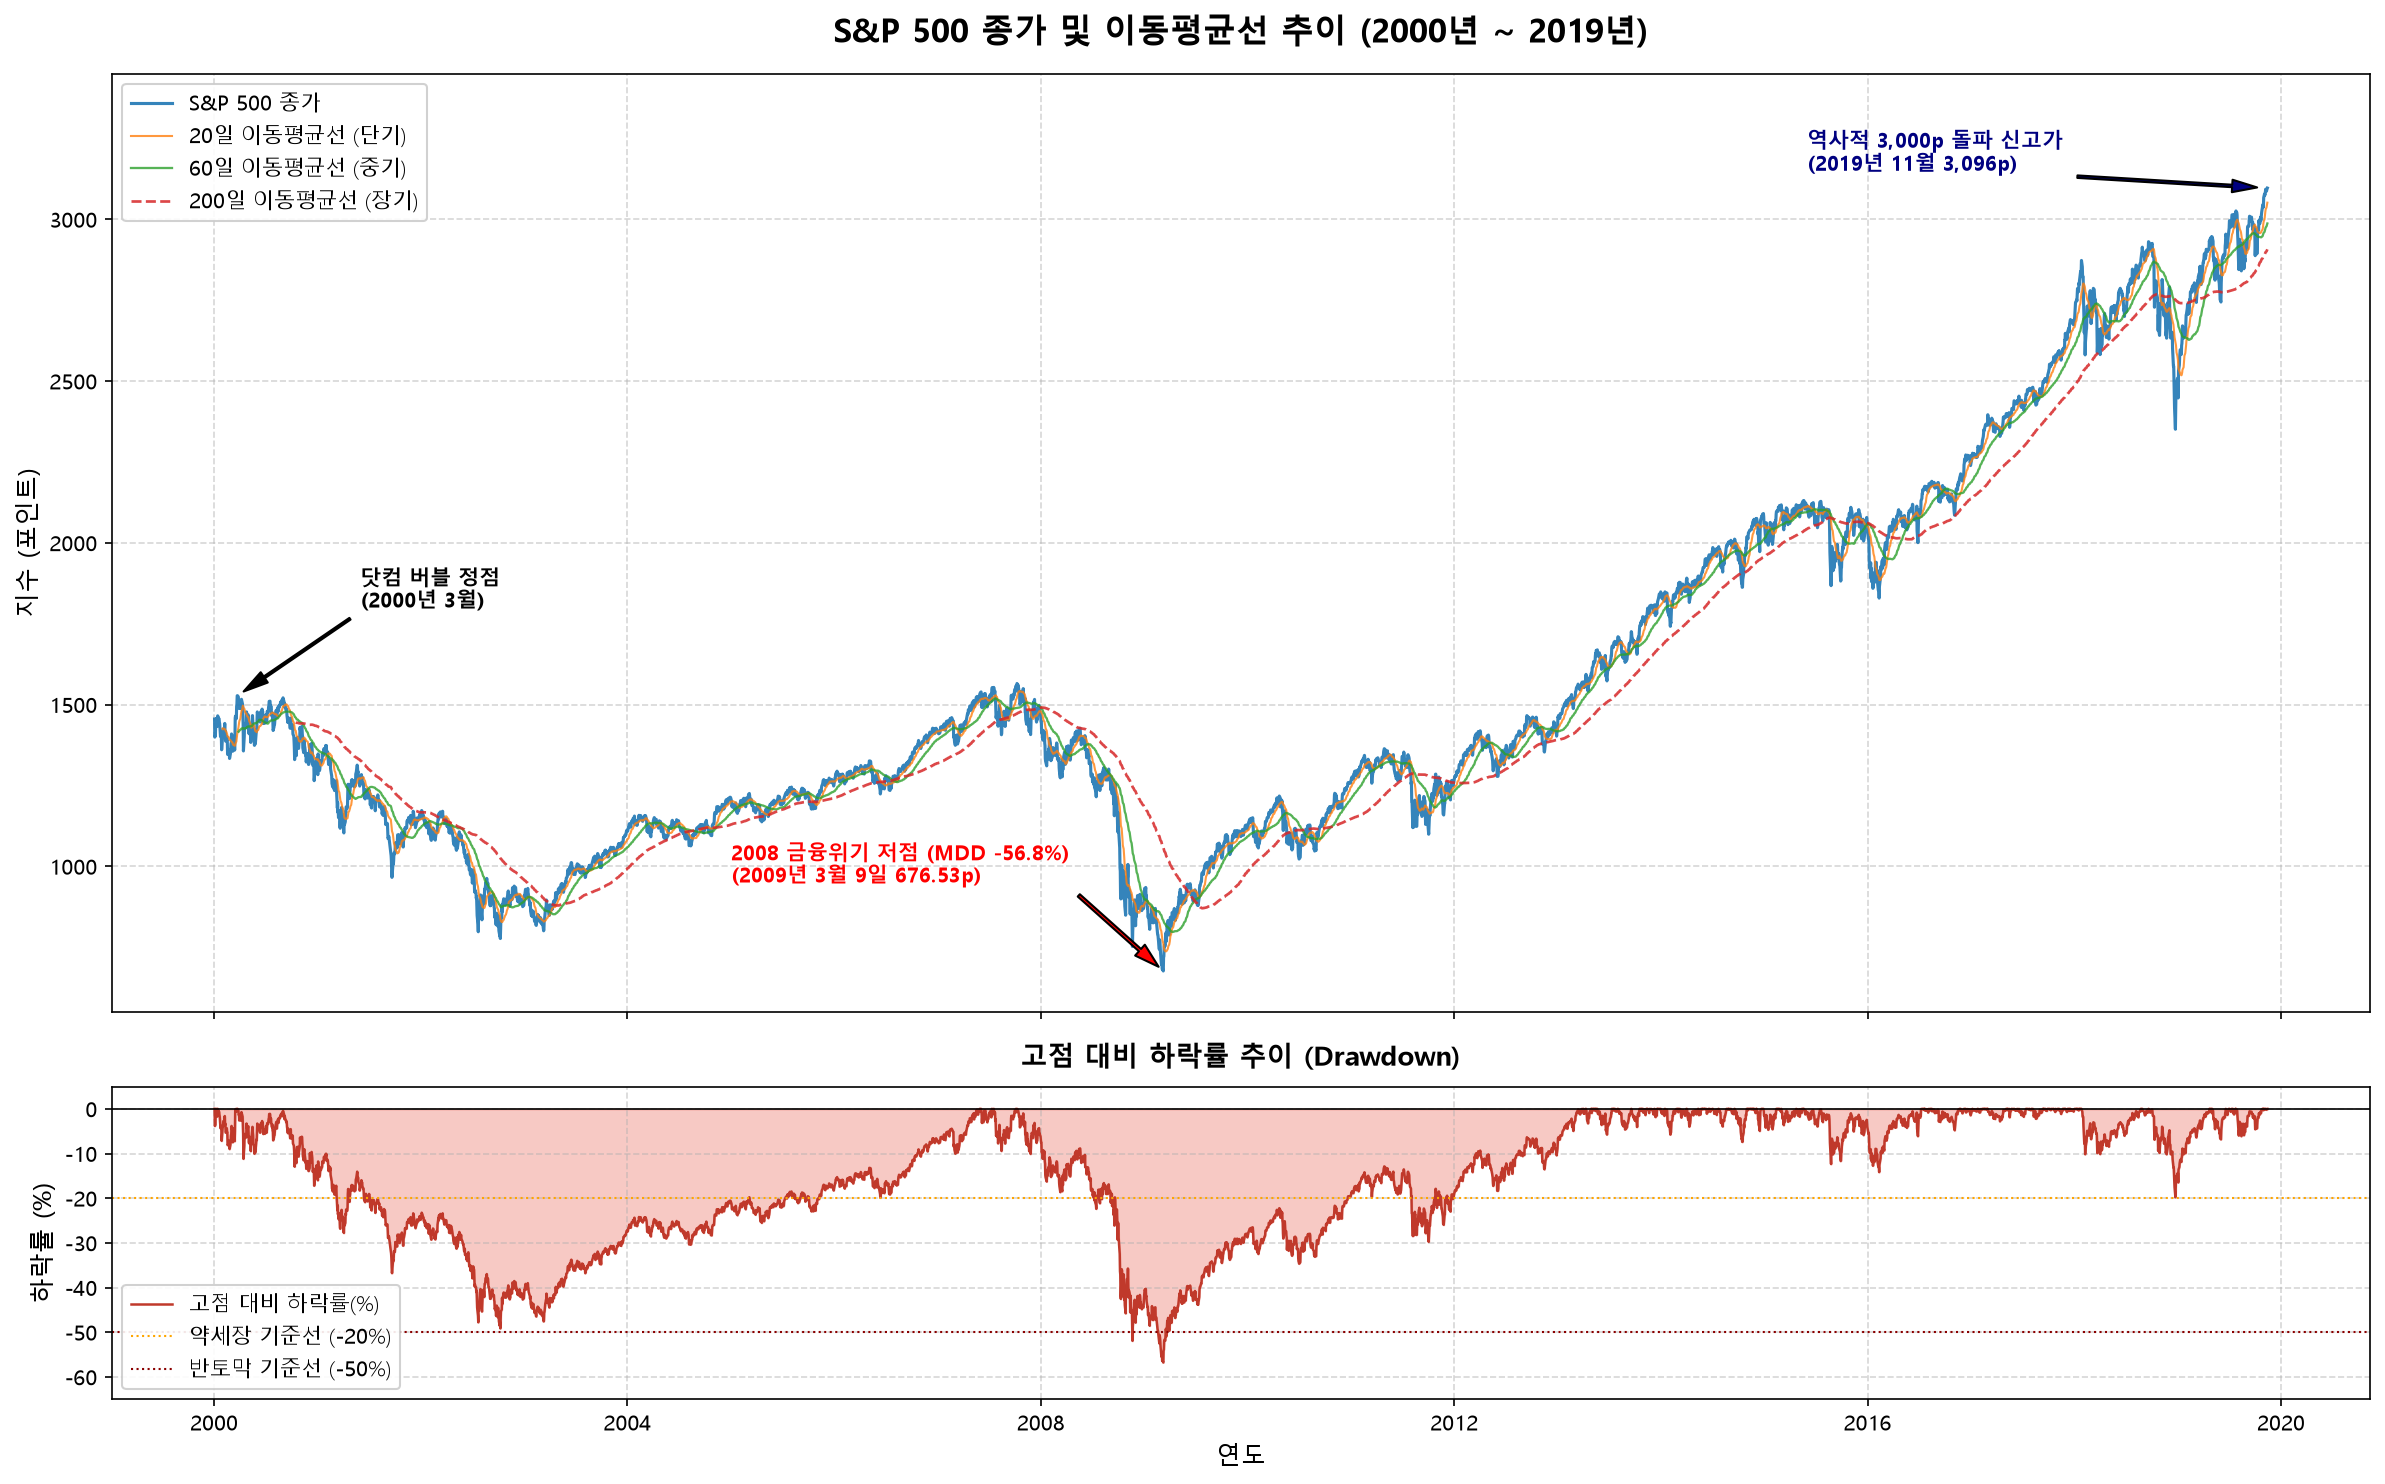

In [ ]:
# 2개 서브플롯 생성: 상단(종가 및 이평선), 하단(고점 대비 하락률 Drawdown)
fig, (ax1, ax2) = plt.subplots(
    nrows=2, 
    ncols=1, 
    figsize=(16, 10), 
    sharex=True, 
    gridspec_kw={"height_ratios": [3, 1]}
)

# [상단 서브플롯: 종가 및 이동평균선]
ax1.plot(df["날짜"], df["종가"], label="S&P 500 종가", color="#1f77b4", linewidth=1.5, alpha=0.9)
ax1.plot(df["날짜"], df["MA20"], label="20일 이동평균선 (단기)", color="#ff7f0e", linewidth=1.0, alpha=0.8)
ax1.plot(df["날짜"], df["MA60"], label="60일 이동평균선 (중기)", color="#2ca02c", linewidth=1.1, alpha=0.8)
ax1.plot(df["날짜"], df["MA200"], label="200일 이동평균선 (장기)", color="#d62728", linewidth=1.3, linestyle="--", alpha=0.85)

# 역사적 주요 사건 주석 (Annotations)
ax1.annotate(
    "닷컴 버블 정점\n(2000년 3월)", 
    xy=(pd.to_datetime("2000-03-24"), 1527.46), 
    xytext=(pd.to_datetime("2001-06-01"), 1800),
    arrowprops=dict(facecolor="black", shrink=0.05, width=1, headwidth=6),
    fontsize=10, fontweight="bold"
)

ax1.annotate(
    "2008 금융위기 저점 (MDD -56.8%)\n(2009년 3월 9일 676.53p)", 
    xy=(pd.to_datetime("2009-03-09"), 676.53), 
    xytext=(pd.to_datetime("2005-01-01"), 950),
    arrowprops=dict(facecolor="red", shrink=0.05, width=1.5, headwidth=7),
    fontsize=10, fontweight="bold", color="red"
)

ax1.annotate(
    "역사적 3,000p 돌파 신고가\n(2019년 11월 3,096p)", 
    xy=(pd.to_datetime("2019-11-14"), 3096.6), 
    xytext=(pd.to_datetime("2015-06-01"), 3150),
    arrowprops=dict(facecolor="navy", shrink=0.05, width=1.2, headwidth=6),
    fontsize=10, fontweight="bold", color="navy"
)

ax1.set_title("S&P 500 종가 및 이동평균선 추이 (2000년 ~ 2019년)", fontsize=16, fontweight="bold", pad=15)
ax1.set_ylabel("지수 (포인트)", fontsize=12)
ax1.set_ylim(550, 3450)
ax1.legend(loc="upper left", frameon=True, framealpha=0.9)
ax1.grid(True, linestyle="--", alpha=0.5)

# [하단 서브플롯: 고점 대비 낙폭(Drawdown)]
ax2.plot(df["날짜"], df["고점대비하락률(%)"], color="#c0392b", linewidth=1.2, label="고점 대비 하락률(%)")
ax2.fill_between(df["날짜"], df["고점대비하락률(%)"], 0, color="#e74c3c", alpha=0.3)
ax2.axhline(0, color="black", linestyle="-", linewidth=0.8)
ax2.axhline(-20, color="orange", linestyle=":", linewidth=1.0, label="약세장 기준선 (-20%)")
ax2.axhline(-50, color="darkred", linestyle=":", linewidth=1.0, label="반토막 기준선 (-50%)")

ax2.set_title("고점 대비 하락률 추이 (Drawdown)", fontsize=13, fontweight="bold", pad=10)
ax2.set_xlabel("연도", fontsize=12)
ax2.set_ylabel("하락률 (%)", fontsize=12)
ax2.set_ylim(-65, 5)
ax2.legend(loc="lower left", frameon=True, framealpha=0.9)
ax2.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()

# 그래프 이미지 파일 저장
output_img = Path("sp500_close_2000_2019.png")
plt.savefig(output_img, dpi=150, bbox_inches="tight")
print(f"그래프 이미지 파일 저장 완료: {output_img.resolve()}")

plt.show()


## 8. 분석 결과 요약 및 인사이트

### 1. 장기 우상향 및 성장성
- 2000년 1월 3일 시가 1,469.20p(종가 1,455.20p)에서 2019년 11월 14일 종가 3,096.60p로 마감하여 **20년간 누적 수익률 약 +112.8%**를 기록했습니다.
- 특히 2008년 글로벌 금융위기의 극단적 저점(2009년 3월 9일 676.53p) 대비로는 **약 +357.7% 이상 반등**하며 미국 증시의 놀라운 회복력과 복리 성장성을 입증했습니다.

### 2. 역사적 리스크와 최대 낙폭 (MDD)
- **최대 낙폭(MDD)**: **-56.78%** (2007년 고점 대비 2009년 3월 9일 저점)
- 2000년 닷컴 버블 붕괴(-49.1%)와 2008년 서브프라임 금융위기(-56.8%)라는 두 번의 대형 하락장을 겪었으며, 하락장을 통과한 후 강력한 장기 상승 국면(Bull Market)이 전개되었습니다.

### 3. 변동성 및 월별 계절성
- **연율화 변동성**: 약 **18.92%**
- 역사적 최대 일일 폭등일(2008-10-13 +11.58%, 2008-10-28 +10.79%)과 최대 폭락일(2008-10-15 -9.03%, 2008-12-01 -8.93%)은 모두 금융위기가 최고조에 달했던 2008년 하반기에 집중되었습니다.
- 월별 계절성 분석에서는 전통적으로 4월과 10월~12월 등 연말 시즌에 높은 상승 확률(승률 65%~75%)을 기록했습니다.
